Fetching data for NVDA and SPY...
Training model...
Directional Accuracy: 57.92%
Mean Absolute Error (Price): $2.86


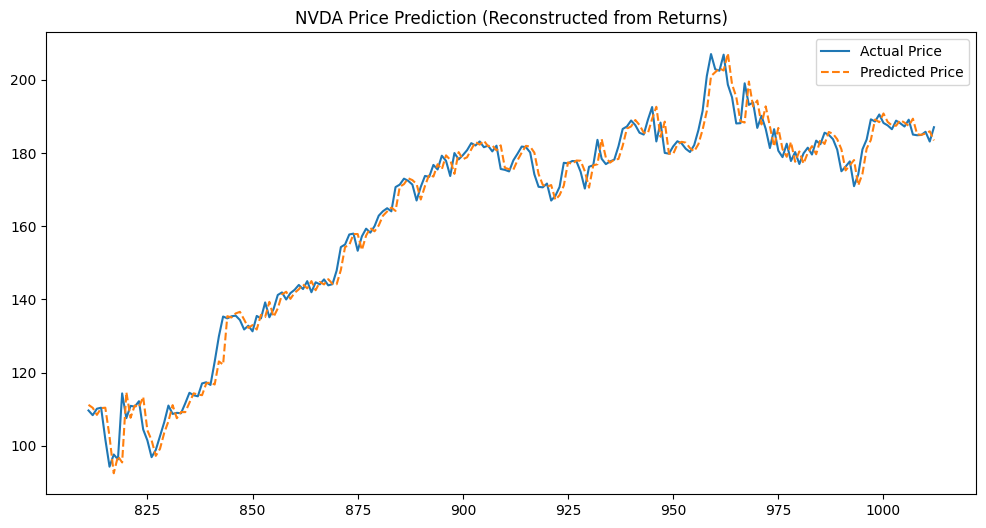

Current Price: $187.05
Predicted Return: 0.17%
Predicted Price Tomorrow: $187.37


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- CONFIGURATION ---
API_KEY = "PKEQBKP4PK7B6LLWOTO7HS456P"
API_SECRET = "2bfKZC9agU4FHaaHveHwKDcsur7xXsTfAy8zgmWxf2ua"
SYMBOL = "NVDA"
MARKET_SYMBOL = "SPY"  # Added Market Context
START_DATE = "2022-01-01"
END_DATE = "2026-01-17" # Keep this in the past for testing

# --- DATA FETCHING ---
client = StockHistoricalDataClient(API_KEY, API_SECRET)

print("Fetching data for NVDA and SPY...")
request_params = StockBarsRequest(
    symbol_or_symbols=[SYMBOL, MARKET_SYMBOL], # Fetch both at once
    timeframe=TimeFrame.Day,
    start=START_DATE,
    end=END_DATE
)

bars = client.get_stock_bars(request_params)
df_all = bars.df.reset_index()

# Separate the two symbols
df = df_all[df_all["symbol"] == SYMBOL].copy()
df_spy = df_all[df_all["symbol"] == MARKET_SYMBOL].copy()

# Rename SPY columns to avoid collision and merge
df_spy = df_spy[["timestamp", "close", "volume"]].rename(
    columns={"close": "spy_close", "volume": "spy_volume"}
)
df = pd.merge(df, df_spy, on="timestamp", how="left")

# --- FEATURE ENGINEERING ---

# 1. TARGET: Predict the Return (Percent Change), NOT the Price
df["return"] = df["close"].pct_change()
df["target"] = df["return"].shift(-1) # Target is tomorrow's return

# 2. MARKET CONTEXT
df["spy_return"] = df["spy_close"].pct_change()

# 3. LAG FEATURES (The "Memory")
# Give the model yesterday's return, 2 days ago, etc.
for lag in [1, 2, 3, 5]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)
    df[f'spy_return_lag_{lag}'] = df['spy_return'].shift(lag)
    df[f'vol_lag_{lag}'] = df['volume'].shift(lag)

# 4. ROLLING AVERAGES (Trends)
df["volatility_5"] = df["return"].rolling(5).std()
df["ma_5"] = df["return"].rolling(5).mean()

# DROP NANS (Critical step)
df.dropna(inplace=True)

features = [
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5",
    "spy_return_lag_1", "spy_return_lag_2",
    "vol_lag_1", "volatility_5", "ma_5"
]

X = df[features]
y = df["target"]

# Split data (Time-series split, no shuffling)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- TRAINING ---
print("Training model...")
model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# --- EVALUATION ---
pred_returns = model.predict(X_test)

# METRIC 1: Directional Accuracy (Did we guess Up/Down correctly?)
# Sign of test vs Sign of prediction
correct_direction = np.sign(y_test) == np.sign(pred_returns)
accuracy = correct_direction.mean() * 100
print(f"Directional Accuracy: {accuracy:.2f}%")

# METRIC 2: Reconstruct Prices to see real error
# We take the "Yesterday" price from the test set and apply our predicted return
test_prices = df["close"].iloc[split:]
# Shift test prices by 1 to get "Yesterday's Price" for each row
yesterday_prices = df["close"].shift(1).iloc[split:] 

# Price = Yesterday * (1 + Predicted_Return)
pred_prices = yesterday_prices * (1 + pred_returns)
actual_prices = test_prices

mae = mean_absolute_error(actual_prices, pred_prices)
print(f"Mean Absolute Error (Price): ${mae:.2f}")

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
plt.plot(actual_prices.index, actual_prices.values, label="Actual Price")
plt.plot(actual_prices.index, pred_prices.values, label="Predicted Price", linestyle="--")
plt.title(f"{SYMBOL} Price Prediction (Reconstructed from Returns)")
plt.legend()
plt.show()

# --- PREDICT TOMORROW ---
# Get the most recent row of data features
latest_data = X.iloc[[-1]] 
next_return = model.predict(latest_data)[0]
current_price = df["close"].iloc[-1]
next_price = current_price * (1 + next_return)

print(f"Current Price: ${current_price:.2f}")
print(f"Predicted Return: {next_return*100:.2f}%")
print(f"Predicted Price Tomorrow: ${next_price:.2f}")